# Graph Features (NetworkX) + GNN (GCN vs GAT)

## 1. Graphe de transactions — NetworkX sur IEEE-CIS

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

from eda_utils import load_train_data
from feature_utils import _build_uid
from graph_utils import build_bipartite_graph, extract_graph_features
from model_utils import evaluate_xgb

### 1.1 Chargement et sous-ensemble de 10 000 transactions

In [ ]:
df = load_train_data("data")
df = df.sort_values("TransactionDT").reset_index(drop=True)
df["uid"] = _build_uid(df)

# Sous-ensemble : 10 000 premières transactions 
sub = df.head(10_000).copy()
sub.shape

C:\Users\mahmo\AppData\Local\Temp\ipykernel_14564\621818868.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["uid"] = _build_uid(df)


(10000, 435)

In [4]:
n_clients = sub["uid"].nunique()
n_merchants = sub["ProductCD"].nunique()
fraud_rate = sub["isFraud"].mean() * 100
print(f"Clients uniques : {n_clients}")
print(f"Marchands (ProductCD) : {n_merchants} — {sub['ProductCD'].unique().tolist()}")
print(f"Taux de fraude : {fraud_rate:.1f}%")

Clients uniques : 6893
Marchands (ProductCD) : 5 — ['W', 'H', 'C', 'S', 'R']
Taux de fraude : 2.6%


### 1.2 Construction du graphe biparti

Graphe biparti : **clients** (uid) ↔ **marchands** (ProductCD).
Chaque transaction crée une arête entre le client et le marchand, avec le montant et le label fraude en attributs.

In [5]:
G = build_bipartite_graph(sub)

print(f"Noeuds : {G.number_of_nodes()} ({n_clients} clients + {n_merchants} marchands)")
print(f"Arêtes : {G.number_of_edges()}")

Noeuds : 6898 (6893 clients + 5 marchands)
Arêtes : 7099


### 1.3 Visualisation du graphe

Les noeuds marchands (5) sont au centre, les clients autour. Les arêtes rouges représentent des transactions frauduleuses.

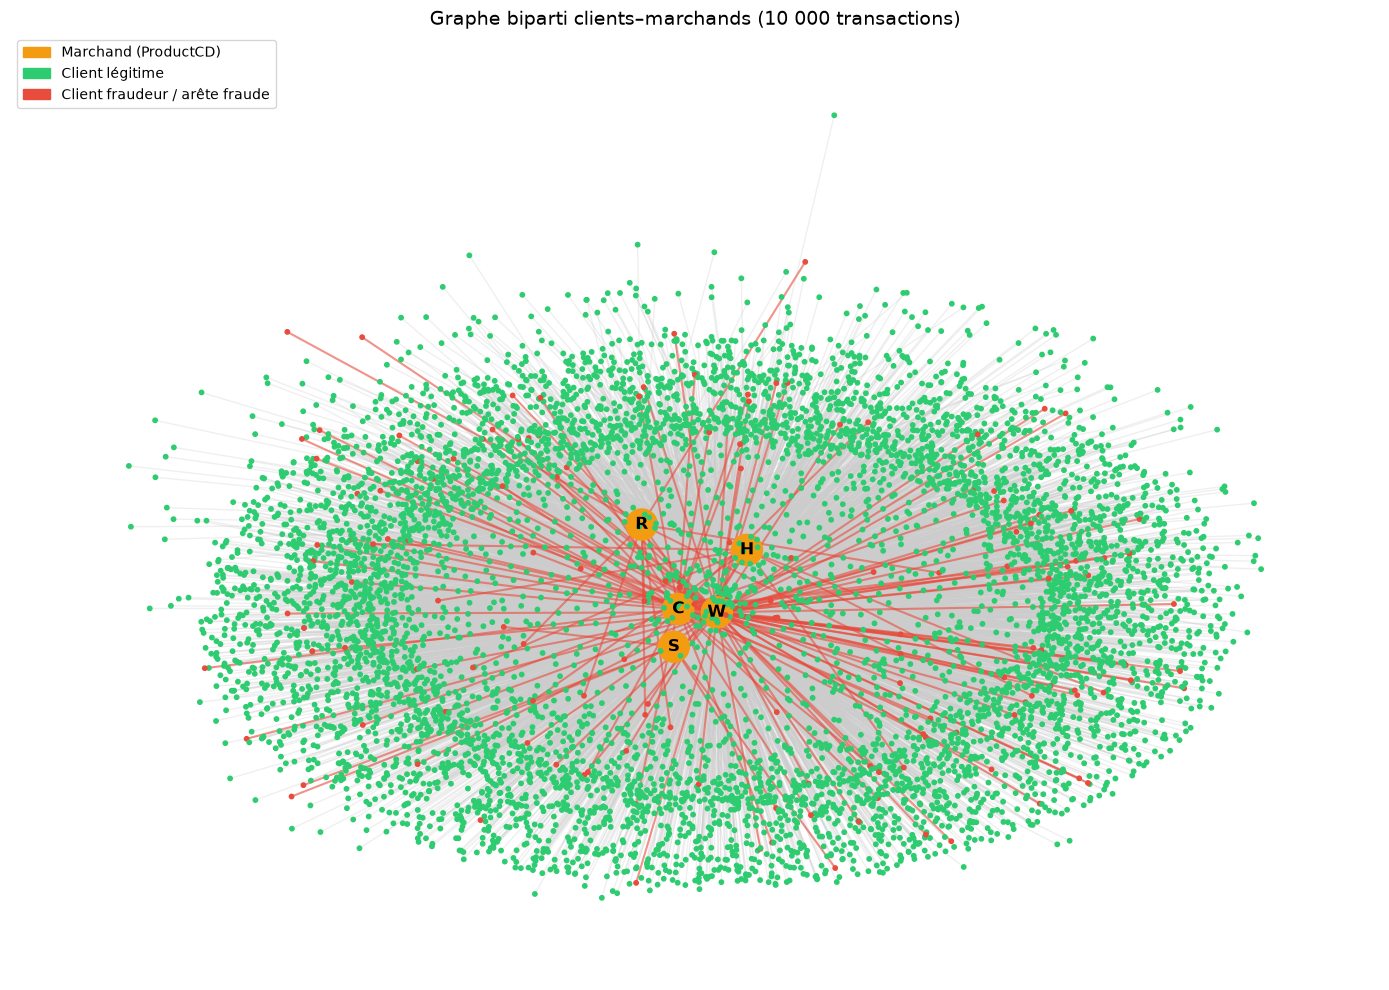

In [8]:
# Calcul du taux de fraude par client pour colorer les noeuds
client_fraud_rate = sub.groupby("uid")["isFraud"].mean()

# Couleurs et tailles des noeuds
node_colors = []
node_sizes = []
for node in G.nodes():
    if G.nodes[node].get("node_type") == "merchant":
        node_colors.append("#f39c12")  # orange pour marchands
        node_sizes.append(500)
    else:
        rate = client_fraud_rate.get(node, 0)
        node_colors.append("#e74c3c" if rate > 0 else "#2ecc71")
        node_sizes.append(10)

# Couleurs des arêtes
edge_colors = ["#e74c3c" if G.edges[e].get("is_fraud", 0) else "#cccccc" for e in G.edges()]

# Visualisation
fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.3, seed=42, iterations=50)

# Arêtes non-fraude d'abord, fraude par-dessus
non_fraud_edges = [e for e in G.edges() if not G.edges[e].get("is_fraud")]
fraud_edges = [e for e in G.edges() if G.edges[e].get("is_fraud")]

nx.draw_networkx_edges(G, pos, edgelist=non_fraud_edges, edge_color="#cccccc", alpha=0.3, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=fraud_edges, edge_color="#e74c3c", alpha=0.6, width=1.5, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, ax=ax)

# Labels marchands uniquement
merchant_nodes = [n for n in G.nodes() if G.nodes[n].get("node_type") == "merchant"]
merchant_labels = {n: G.nodes[n]["label"] for n in merchant_nodes}
nx.draw_networkx_labels(G, pos, labels=merchant_labels, font_size=12, font_weight="bold", ax=ax)

legend = [
    mpatches.Patch(color="#f39c12", label="Marchand (ProductCD)"),
    mpatches.Patch(color="#2ecc71", label="Client légitime"),
    mpatches.Patch(color="#e74c3c", label="Client fraudeur / arête fraude"),
]
ax.legend(handles=legend, loc="upper left", fontsize=10)
ax.set_title("Graphe biparti clients–marchands (10 000 transactions)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

### 1.4 Zoom sur un cluster suspect

On identifie le marchand avec le plus haut taux de fraude et on extrait le sous-graphe de ses clients pour visualiser le cluster.

In [8]:
# Taux de fraude par marchand
merchant_stats = sub.groupby("ProductCD").agg(
    nb_tx=("isFraud", "count"),
    nb_fraud=("isFraud", "sum"),
    taux_fraude=("isFraud", "mean"),
).sort_values("taux_fraude", ascending=False)
merchant_stats["taux_fraude"] = (merchant_stats["taux_fraude"] * 100).round(2)
merchant_stats

,nb_tx,nb_fraud,taux_fraude
ProductCD,,,
C,906,94,10.38
R,305,17,5.57
S,209,10,4.78
W,7709,132,1.71
H,871,12,1.38


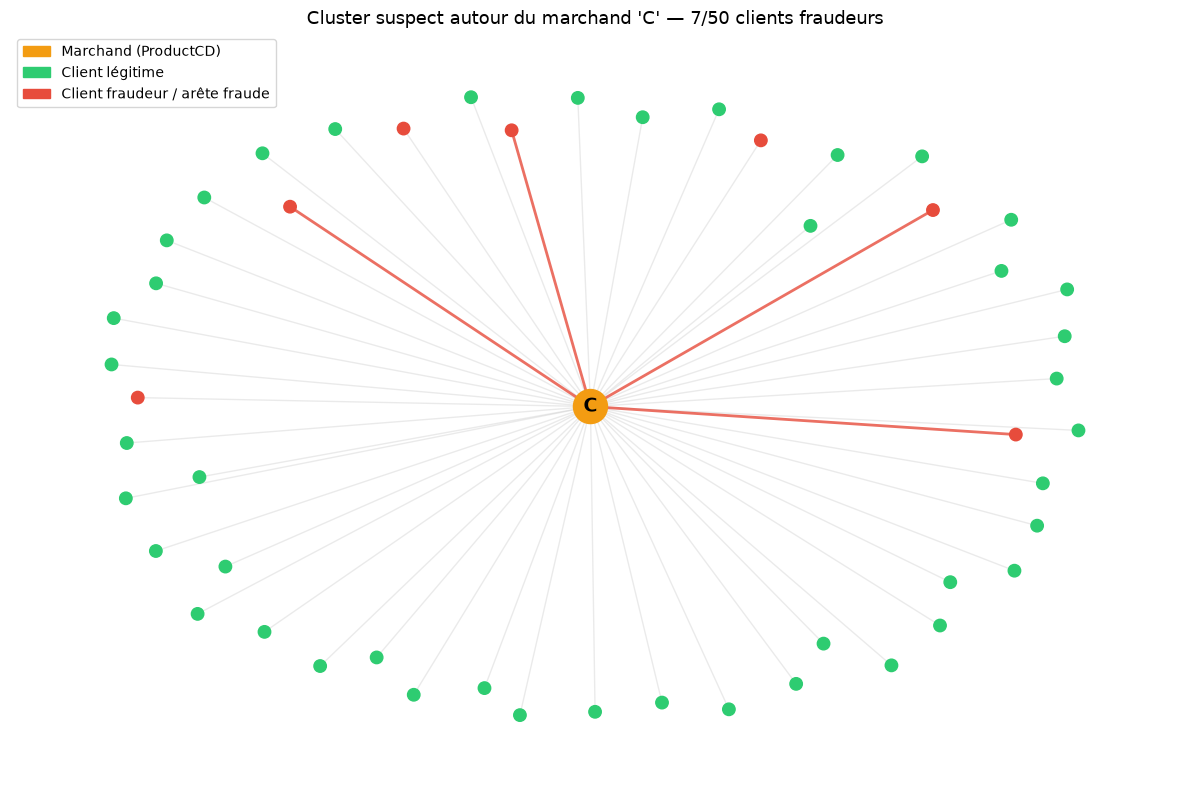

In [ ]:
# Sous-graphe : marchand le plus frauduleux et ses clients
top_merchant = f"M_{merchant_stats.index[0]}"
suspect_clients = [n for n in G.neighbors(top_merchant)]

# 50 clients avec le plus de connexions pour lisibilité
suspect_degrees = {c: G.degree(c) for c in suspect_clients}
top_suspects = sorted(suspect_degrees, key=suspect_degrees.get, reverse=True)[:50]

sub_nodes = top_suspects + [top_merchant]
S = G.subgraph(sub_nodes)

# Visualisation du sous-graphe
fig, ax = plt.subplots(figsize=(12, 8))
pos_s = nx.spring_layout(S, k=1.5, seed=42)

s_node_colors = []
s_node_sizes = []
for node in S.nodes():
    if S.nodes[node].get("node_type") == "merchant":
        s_node_colors.append("#f39c12")
        s_node_sizes.append(600)
    else:
        rate = client_fraud_rate.get(node, 0)
        s_node_colors.append("#e74c3c" if rate > 0 else "#2ecc71")
        s_node_sizes.append(80)

s_fraud_edges = [e for e in S.edges() if S.edges[e].get("is_fraud")]
s_legit_edges = [e for e in S.edges() if not S.edges[e].get("is_fraud")]

nx.draw_networkx_edges(S, pos_s, edgelist=s_legit_edges, edge_color="#cccccc", alpha=0.4, ax=ax)
nx.draw_networkx_edges(S, pos_s, edgelist=s_fraud_edges, edge_color="#e74c3c", alpha=0.8, width=2, ax=ax)
nx.draw_networkx_nodes(S, pos_s, node_color=s_node_colors, node_size=s_node_sizes, ax=ax)

merchant_labels_s = {n: S.nodes[n]["label"] for n in S.nodes() if S.nodes[n].get("node_type") == "merchant"}
nx.draw_networkx_labels(S, pos_s, labels=merchant_labels_s, font_size=14, font_weight="bold", ax=ax)

n_fraud_clients = sum(1 for c in top_suspects if client_fraud_rate.get(c, 0) > 0)
ax.set_title(f"Cluster suspect autour du marchand '{merchant_stats.index[0]}' — "
             f"{n_fraud_clients}/{len(top_suspects)} clients fraudeurs", fontsize=13)
ax.legend(handles=legend, loc="upper left", fontsize=10)
plt.axis("off")
plt.tight_layout()
plt.show()

### 1.5 Extraction de features graphe

Pour chaque client, on extrait :
- **Degré** : nombre de transactions (arêtes) du client
- **Nombre de marchands distincts sur 7 jours** : diversité des ProductCD
- **Centralité betweenness** : mesure l'importance d'un noeud comme pont entre communautés (calculée sur le sous-graphe de 10k car trop coûteux sur 590k)

In [10]:
graph_features = extract_graph_features(df, G)
graph_features.describe().round(4)

c:\Users\mahmo\OneDrive\Documents\fraud-scope\graph_utils.py:48: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.assign(day=day)


,graph_degree,graph_merchants_7d,graph_betweenness
count,217850.0000,217850.0000,217850.0000
mean,2.7108,1.0442,0.0000
std,5.4578,0.2314,0.0002
min,1.0000,1.0000,0.0000
25%,1.0000,1.0000,0.0000
50%,1.0000,1.0000,0.0000
75%,3.0000,1.0000,0.0000
max,1414.0000,4.0000,0.0917


### 1.6 Intégration dans XGBoost — comparaison AUPRC

On compare un XGBoost entraîné **sans** features graphe vs **avec** features graphe, en utilisant `TimeSeriesSplit` pour respecter l'ordre temporel.

In [ ]:
df_feat = pd.read_csv("data/train_featured.csv")

# Ajouter le uid pour joindre les features graphe
df_raw = load_train_data("data").sort_values("TransactionDT").reset_index(drop=True)
df_feat["uid"] = _build_uid(df_raw)

# Joindre les features graphe
df_with_graph = df_feat.join(graph_features, on="uid", how="left")
df_with_graph[["graph_degree", "graph_merchants_7d", "graph_betweenness"]] = (
    df_with_graph[["graph_degree", "graph_merchants_7d", "graph_betweenness"]].fillna(0)
)
df_with_graph = df_with_graph.drop(columns=["uid"])

y = df_feat["isFraud"]
X_base = df_feat.drop(columns=["isFraud", "uid"])
X_graph = df_with_graph.drop(columns=["isFraud"])

# Comparaison avec et sans features graphe
results_base = evaluate_xgb(X_base, y, "XGBoost SANS features graphe")
results_graph = evaluate_xgb(X_graph, y, "XGBoost AVEC features graphe")

C:\Users\mahmo\AppData\Local\Temp\ipykernel_22580\3433514713.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_feat["uid"] = _build_uid(df_raw)


In [ ]:
comparison = pd.DataFrame({
    "Modèle": ["XGBoost (sans graphe)", "XGBoost (avec graphe)"],
    "AUPRC moyen": [results_base["auprc"].mean(), results_graph["auprc"].mean()],
    "Recall moyen": [results_base["recall"].mean(), results_graph["recall"].mean()],
    "F1 moyen": [results_base["f1"].mean(), results_graph["f1"].mean()],
}).round(4)

delta = results_graph["auprc"].mean() - results_base["auprc"].mean()
print(f"Gain AUPRC avec features graphe : {delta:+.4f}")
comparison

Gain AUPRC avec features graphe : +0.0135


,Modèle,AUPRC moyen,Recall moyen,F1 moyen
0,XGBoost (sans graphe),0.5149,0.6537,0.3658
1,XGBoost (avec graphe),0.5284,0.6699,0.3778


## 2. GNN sur Elliptic Bitcoin — GCN vs GAT

Dataset Elliptic : ~200k transactions Bitcoin, chaque noeud = transaction avec 166 features, arêtes = flux de BTC entre transactions. Labels : illicit (fraude) / licit / unknown.

### 2.1 Chargement du dataset Elliptic

In [1]:
import torch
import time
from torch_geometric.datasets import EllipticBitcoinDataset
from gnn_utils import GCN, GAT, train_gnn, evaluate_gnn

dataset = EllipticBitcoinDataset(root="data/elliptic")
data = dataset[0]

print(f"Noeuds : {data.num_nodes}")
print(f"Arêtes : {data.num_edges}")
print(f"Features par noeud : {data.num_node_features}")
print(f"Classes : {dataset.num_classes}")
print(f"Labels : {data.y.unique().tolist()}")

Noeuds : 203769
Arêtes : 234355
Features par noeud : 165
Classes : 2
Labels : [0, 1, 2]


### 2.3 Préparation des masques train/test

Le dataset contient 3 labels : **0** = licit, **1** = illicit, **2** = unknown. On ignore les unknown et on ne garde que les noeuds labellisés.

Les données sont réparties sur **49 timesteps**. On fait un split temporel 70/30 : les premiers timesteps pour le train, les derniers pour le test.

In [2]:
# Labels : 0=licit, 1=illicit, 2=unknown
labeled_mask = data.y != 2

# Split temporel via le timestep (feature index 0 = timestep)
timesteps = data.x[:, 0]
unique_ts = timesteps.unique().sort()[0]
split_ts = unique_ts[int(len(unique_ts) * 0.7)]

train_mask = labeled_mask & (timesteps <= split_ts)
test_mask = labeled_mask & (timesteps > split_ts)

y = data.y.clone()
y[y == 2] = 0  # unknown -> 0 (ne sera pas utilisé grâce aux masques)

print(f"Train : {train_mask.sum().item()} noeuds")
print(f"Test  : {test_mask.sum().item()} noeuds")
print(f"Taux fraude train : {y[train_mask].float().mean():.2%}")
print(f"Taux fraude test  : {y[test_mask].float().mean():.2%}")

Train : 36289 noeuds
Test  : 10275 noeuds
Taux fraude train : 12.04%
Taux fraude test  : 1.71%


### 2.3 Entraînement GCN vs GAT

Les modèles `GCN` et `GAT` (2 couches chacun) ainsi que les fonctions `train_gnn` / `evaluate_gnn` sont définis dans `gnn_utils.py`.

In [3]:
in_channels = data.num_node_features
hidden = 64

# GCN
torch.manual_seed(42)
gcn = GCN(in_channels, hidden)
start = time.time()
gcn = train_gnn(gcn, data, y, train_mask, epochs=100)
gcn_train_time = time.time() - start
gcn_metrics = evaluate_gnn(gcn, data, y, test_mask)
gcn_metrics["train_s"] = round(gcn_train_time, 2)
print(f"GCN — AUPRC: {gcn_metrics['auprc']:.4f}  Recall: {gcn_metrics['recall']:.4f}  F1: {gcn_metrics['f1']:.4f}  Train: {gcn_metrics['train_s']}s  Inference: {gcn_metrics['inference_ms']}ms")

# GAT
torch.manual_seed(42)
gat = GAT(in_channels, hidden, heads=4)
start = time.time()
gat = train_gnn(gat, data, y, train_mask, epochs=100)
gat_train_time = time.time() - start
gat_metrics = evaluate_gnn(gat, data, y, test_mask)
gat_metrics["train_s"] = round(gat_train_time, 2)
print(f"GAT — AUPRC: {gat_metrics['auprc']:.4f}  Recall: {gat_metrics['recall']:.4f}  F1: {gat_metrics['f1']:.4f}  Train: {gat_metrics['train_s']}s  Inference: {gat_metrics['inference_ms']}ms")

GCN — AUPRC: 0.1323  Recall: 0.9034  F1: 0.1627  Train: 127.22s  Inference: 330.7ms
GAT — AUPRC: 0.2499  Recall: 0.9489  F1: 0.1188  Train: 500.14s  Inference: 1204.2ms


### 2.4 Comparaison GCN vs GAT

In [6]:
comparison_gnn = pd.DataFrame({
    "Modèle": ["GCN (2 couches)", "GAT (2 couches, 4 heads)"],
    "AUPRC": [gcn_metrics["auprc"], gat_metrics["auprc"]],
    "Recall": [gcn_metrics["recall"], gat_metrics["recall"]],
    "F1": [gcn_metrics["f1"], gat_metrics["f1"]],
    "Train (s)": [gcn_metrics["train_s"], gat_metrics["train_s"]],
    "Inference (ms)": [gcn_metrics["inference_ms"], gat_metrics["inference_ms"]],
}).round(4)
comparison_gnn

,Modèle,AUPRC,Recall,F1,Train (s),Inference (ms)
0,GCN (2 couches),0.1323,0.9034,0.1627,127.22,330.7
1,"GAT (2 couches, 4 heads)",0.2499,0.9489,0.1188,500.14,1204.2
